## **Medicine Analytics | EDA**

Importing neccesary libraries and loading dataset

In [1]:
import pandas as pd
import numpy as np

df_med = pd.read_csv("/content/medicine.csv")

In [2]:
df_med.head()

,brand id,brand name,type,slug,dosage form,generic,strength,manufacturer,package container,Package Size
0,4077,A-Cold,allopathic,a-coldsyrup4-mg5-ml,Syrup,Bromhexine Hydrochloride,4 mg/5 ml,ACME Laboratories Ltd.,100 ml bottle: ৳ 40.12,NaN
1,4006,A-Cof,allopathic,a-cofsyrup10-mg30-mg125-mg5-ml,Syrup,Dextromethorphan + Pseudoephedrine + Triprolidine,(10 mg+30 mg+1.25 mg)/5 ml,ACME Laboratories Ltd.,100 ml bottle: ৳ 100.00,NaN
2,6174,A-Clox,allopathic,a-cloxinjection500-mgvial,Injection,Cloxacillin Sodium,500 mg/vial,ACME Laboratories Ltd.,"500 mg vial: ৳ 28.43,(5's pack: ৳ 142.15),",(5's pack: ৳ 142.15)
3,6173,A-Clox,allopathic,a-cloxinjection250-mgvial,Injection,Cloxacillin Sodium,250 mg/vial,ACME Laboratories Ltd.,"250 mg vial: ৳ 20.00,(5's pack: ৳ 100.00),",(5's pack: ৳ 100.00)
4,6172,A-Clox,allopathic,a-cloxpowder-for-suspension125-mg5-ml,Powder for Suspension,Cloxacillin Sodium,125 mg/5 ml,ACME Laboratories Ltd.,100 ml bottle: ৳ 45.00,NaN


In [3]:
df_med.shape

(21714, 10)

In [4]:
df_med.describe()

,brand id
count,21714.000000
mean,16370.435019
std,10289.034379
min,1.000000
25%,7374.250000
50%,14587.500000
75%,27078.750000
max,33198.000000


In [6]:
df_med.columns

Index(['brand id', 'brand name', 'type', 'slug', 'dosage form', 'generic',
       'strength', 'manufacturer', 'package container', 'Package Size'],
      dtype='object')

ID and slug are not neccesary, so let's drop those two

In [8]:
df_med.drop(['brand id', 'slug'], axis=1, inplace=True)

In [10]:
df_med.head()

,brand name,type,dosage form,generic,strength,manufacturer,package container,Package Size
0,A-Cold,allopathic,Syrup,Bromhexine Hydrochloride,4 mg/5 ml,ACME Laboratories Ltd.,100 ml bottle: ৳ 40.12,NaN
1,A-Cof,allopathic,Syrup,Dextromethorphan + Pseudoephedrine + Triprolidine,(10 mg+30 mg+1.25 mg)/5 ml,ACME Laboratories Ltd.,100 ml bottle: ৳ 100.00,NaN
2,A-Clox,allopathic,Injection,Cloxacillin Sodium,500 mg/vial,ACME Laboratories Ltd.,"500 mg vial: ৳ 28.43,(5's pack: ৳ 142.15),",(5's pack: ৳ 142.15)
3,A-Clox,allopathic,Injection,Cloxacillin Sodium,250 mg/vial,ACME Laboratories Ltd.,"250 mg vial: ৳ 20.00,(5's pack: ৳ 100.00),",(5's pack: ৳ 100.00)
4,A-Clox,allopathic,Powder for Suspension,Cloxacillin Sodium,125 mg/5 ml,ACME Laboratories Ltd.,100 ml bottle: ৳ 45.00,NaN


In [11]:
df_med.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21714 entries, 0 to 21713
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   brand name         21714 non-null  object
 1   type               21714 non-null  object
 2   dosage form        21714 non-null  object
 3   generic            21712 non-null  object
 4   strength           20865 non-null  object
 5   manufacturer       21714 non-null  object
 6   package container  21672 non-null  object
 7   Package Size       13935 non-null  object
dtypes: object(8)
memory usage: 1.3+ MB


Checking duplicates

In [13]:
print('Known observations: {}\nUnique observations: {}'.format(len(df_med.index),len(df_med.drop_duplicates().index)))

print("**No duplicates Found!**")

Known observations: 21714
Unique observations: 21708
**No duplicates Found!**


Summary of features

In [14]:
df_med.describe(include=['object']).T

,count,unique,top,freq
brand name,21714,13934,Bexitrol F,9
type,21714,2,allopathic,21363
dosage form,21714,112,Tablet,9329
generic,21712,1661,Cefixime Trihydrate,341
strength,20865,1033,500 mg,1298
manufacturer,21714,232,Incepta Pharmaceuticals Ltd.,1182
package container,21672,7364,"Unit Price: ৳ 10.00,(30's pack: ৳ 300.00),",505
Package Size,13935,3531,(30's pack: ৳ 300.00),509


Number of rows with at least 1 missing values: 8235
Number of columns with missing values: 4

Missing percentage (desceding):


,Total,Percentage(%)
Package Size,7779,35.824813
strength,849,3.909920
package container,42,0.193424
generic,2,0.009211


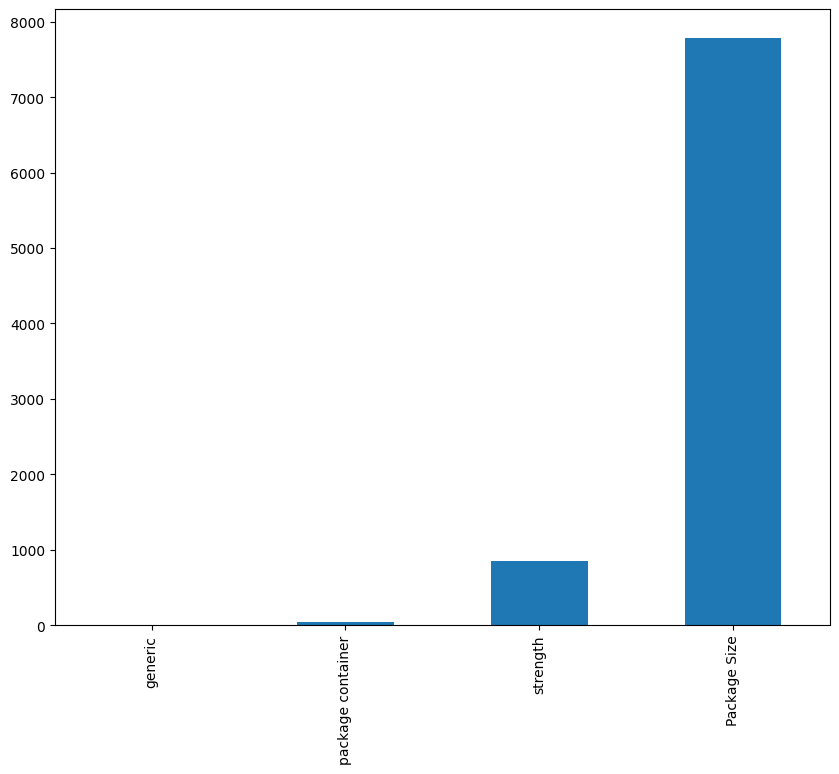

In [18]:
missing_value_describe(df_med)

## Visualizing data

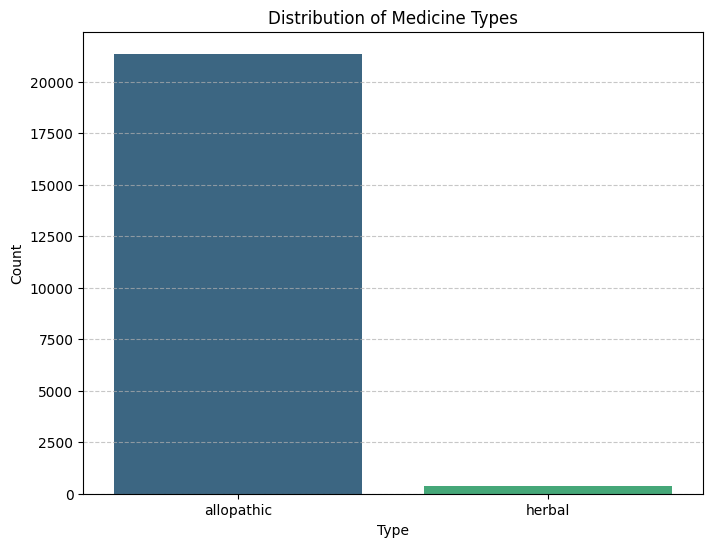

In [25]:
import matplotlib.pyplot as plt
import seaborn as sns

# Value counts for 'type' column
type_counts = df_med['type'].value_counts()

fig = plt.figure(figsize=(8, 6))
sns.barplot(x=type_counts.index, y=type_counts.values, palette='viridis', hue=type_counts.index, legend=False)
plt.title('Distribution of Medicine Types')
plt.xlabel('Type')
plt.ylabel('Count')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

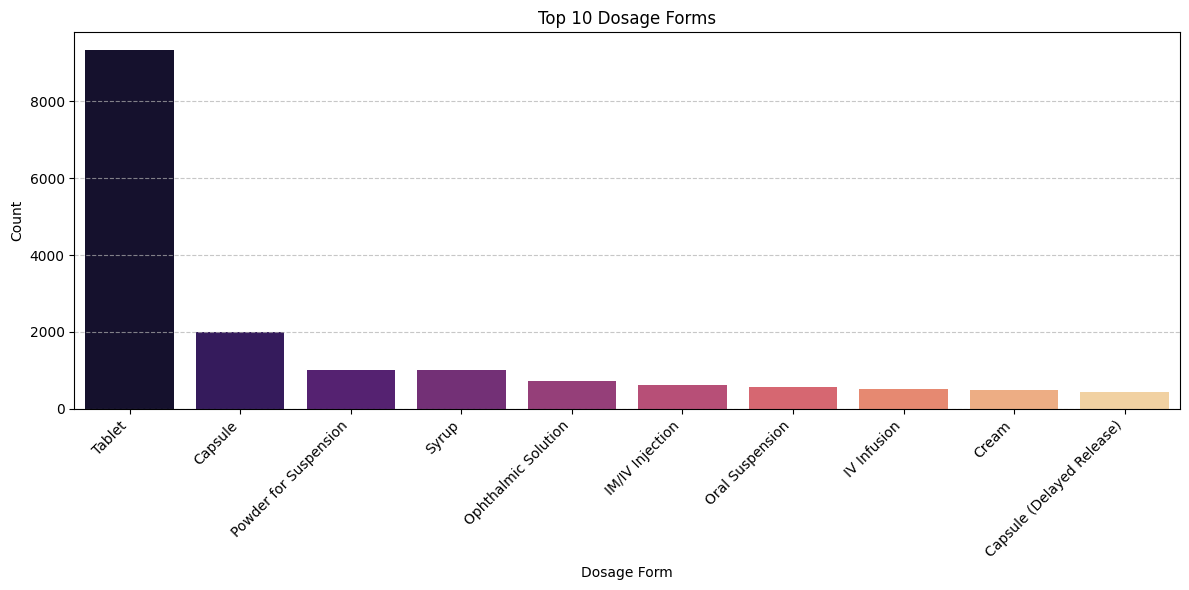

In [26]:
import matplotlib.pyplot as plt
import seaborn as sns

# Value counts for 'dosage form' column (top 10)
dosage_form_counts = df_med['dosage form'].value_counts().head(10)

fig = plt.figure(figsize=(12, 6))
sns.barplot(x=dosage_form_counts.index, y=dosage_form_counts.values, palette='magma', hue=dosage_form_counts.index, legend=False)
plt.title('Top 10 Dosage Forms')
plt.xlabel('Dosage Form')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

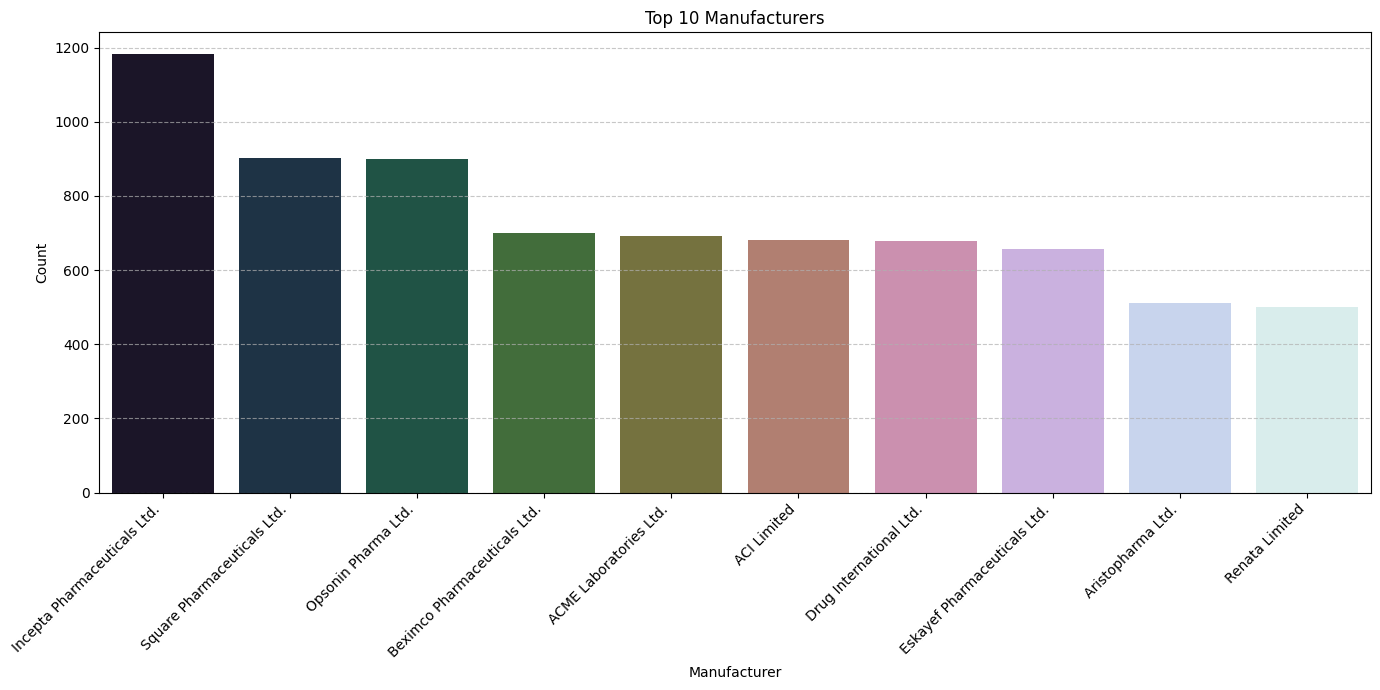

In [27]:
import matplotlib.pyplot as plt
import seaborn as sns

# Value counts for 'manufacturer' column (top 10)
manufacturer_counts = df_med['manufacturer'].value_counts().head(10)

fig = plt.figure(figsize=(14, 7))
sns.barplot(x=manufacturer_counts.index, y=manufacturer_counts.values, palette='cubehelix', hue=manufacturer_counts.index, legend=False)
plt.title('Top 10 Manufacturers')
plt.xlabel('Manufacturer')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

## **Data Cleaning and Transformation**

In [28]:
import re

def extract_package_size(package_size_str):
    if pd.isna(package_size_str):
        return None, None

    # Try to extract quantity and unit from patterns like 'X's pack', 'X ml', 'X gm', 'X mg'
    match_pack = re.search(r'(\d+)\'s pack', str(package_size_str))
    match_ml = re.search(r'(\d+)\s*ml', str(package_size_str))
    match_gm = re.search(r'(\d+)\s*gm', str(package_size_str))
    match_mg = re.search(r'(\d+)\s*mg', str(package_size_str))
    match_unit_price = re.search(r'Unit Price: ৳\s*([\d.]+)', str(package_size_str))

    if match_pack:
        return int(match_pack.group(1)), 'pack'
    elif match_ml:
        return float(match_ml.group(1)), 'ml'
    elif match_gm:
        return float(match_gm.group(1)), 'gm'
    elif match_mg:
        return float(match_mg.group(1)), 'mg'
    elif match_unit_price:
        # If only unit price is found, quantity is usually 1 for unit, or inferred from package container
        return 1, 'unit_price_ref'
    else:
        # Fallback for other patterns or no match
        numeric_vals = re.findall(r'\d+\.?\d*', str(package_size_str))
        if numeric_vals:
            # Take the first numerical value as quantity if no clear unit
            return float(numeric_vals[0]), 'unknown_unit'
    return None, None

# Apply the function to create new columns
df_med['package_quantity'] = None
df_med['package_unit'] = None

for index, row in df_med.iterrows():
    quantity, unit = extract_package_size(row['Package Size'])
    if quantity is None:
        # If 'Package Size' didn't yield results, try 'package container' for quantity
        quantity_container, unit_container = extract_package_size(row['package container'])
        if quantity_container is not None:
            df_med.loc[index, 'package_quantity'] = quantity_container
            df_med.loc[index, 'package_unit'] = unit_container
    else:
        df_med.loc[index, 'package_quantity'] = quantity
        df_med.loc[index, 'package_unit'] = unit


# Extracting price from 'package container'
def extract_price(container_str):
    if pd.isna(container_str):
        return None
    match_price = re.search(r'৳\s*([\d.]+)', str(container_str))
    if match_price:
        return float(match_price.group(1))
    return None

df_med['unit_price'] = df_med['package container'].apply(extract_price)

print("Extracted 'package_quantity', 'package_unit', and 'unit_price' columns.")
display(df_med[['Package Size', 'package container', 'package_quantity', 'package_unit', 'unit_price']].head())

Extracted 'package_quantity', 'package_unit', and 'unit_price' columns.


,Package Size,package container,package_quantity,package_unit,unit_price
0,NaN,100 ml bottle: ৳ 40.12,100.0,ml,40.12
1,NaN,100 ml bottle: ৳ 100.00,100.0,ml,100.00
2,(5's pack: ৳ 142.15),"500 mg vial: ৳ 28.43,(5's pack: ৳ 142.15),",5,pack,28.43
3,(5's pack: ৳ 100.00),"250 mg vial: ৳ 20.00,(5's pack: ৳ 100.00),",5,pack,20.00
4,NaN,100 ml bottle: ৳ 45.00,100.0,ml,45.00


In [29]:
# Convert 'package_quantity' to numeric, coercing errors
df_med['package_quantity'] = pd.to_numeric(df_med['package_quantity'], errors='coerce')

# Impute missing 'package_quantity' values based on the mode for each 'dosage form' and 'strength' combination
df_med['package_quantity'] = df_med.groupby(['dosage form', 'strength'])['package_quantity'].transform(lambda x: x.fillna(x.mode()[0] if not x.mode().empty else x.median()))

# For remaining missing 'package_quantity' after grouped imputation, fill with overall mode
df_med['package_quantity'] = df_med['package_quantity'].fillna(df_med['package_quantity'].mode()[0])

# Fill missing 'package_unit' with the mode
df_med['package_unit'] = df_med['package_unit'].fillna(df_med['package_unit'].mode()[0])

# Impute missing 'unit_price' with the median for each 'dosage form' and 'strength' combination
df_med['unit_price'] = df_med.groupby(['dosage form', 'strength'])['unit_price'].transform(lambda x: x.fillna(x.median()))

# For remaining missing 'unit_price' after grouped imputation, fill with overall median
df_med['unit_price'] = df_med['unit_price'].fillna(df_med['unit_price'].median())

print("Missing values in 'package_quantity', 'package_unit', and 'unit_price' have been handled.")
print("Updated info for relevant columns:")
display(df_med[['package_quantity', 'package_unit', 'unit_price']].info())

Missing values in 'package_quantity', 'package_unit', and 'unit_price' have been handled.
Updated info for relevant columns:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21714 entries, 0 to 21713
Data columns (total 3 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   package_quantity  21714 non-null  float64
 1   package_unit      21714 non-null  object 
 2   unit_price        21714 non-null  float64
dtypes: float64(2), object(1)
memory usage: 509.1+ KB


None

In [30]:
# Extract numerical strength and unit
def extract_strength(strength_str):
    if pd.isna(strength_str):
        return None, None

    # Handle complex strengths like '(X mg + Y mg)/Z ml'
    if '+' in str(strength_str):
        # Extract all numbers and sum them, take the last unit
        numbers = re.findall(r'(\d+\.?\d*)', str(strength_str))
        units = re.findall(r'(mg|ml|gm|%|IU|mcg|unit)', str(strength_str))
        if numbers and units:
            total_strength = sum(float(n) for n in numbers)
            return total_strength, units[-1]
        return None, None

    match = re.search(r'(\d+\.?\d*)\s*(mg|ml|gm|%|IU|mcg|unit)', str(strength_str), re.IGNORECASE)
    if match:
        return float(match.group(1)), match.group(2).lower()
    return None, None

df_med['strength_value'] = None
df_med['strength_unit'] = None

for index, row in df_med.iterrows():
    value, unit = extract_strength(row['strength'])
    df_med.loc[index, 'strength_value'] = value
    df_med.loc[index, 'strength_unit'] = unit

# Convert 'strength_value' to numeric, coercing errors
df_med['strength_value'] = pd.to_numeric(df_med['strength_value'], errors='coerce')

# Impute missing 'strength_value' with the median for each 'dosage form' and 'package_unit' combination
df_med['strength_value'] = df_med.groupby(['dosage form', 'package_unit'])['strength_value'].transform(lambda x: x.fillna(x.median()))

# For remaining missing 'strength_value' after grouped imputation, fill with overall median
df_med['strength_value'] = df_med['strength_value'].fillna(df_med['strength_value'].median())

# Fill missing 'strength_unit' with the mode
df_med['strength_unit'] = df_med['strength_unit'].fillna(df_med['strength_unit'].mode()[0])

print("Extracted and imputed 'strength_value' and 'strength_unit' columns.")
print("Updated info for relevant columns:")
display(df_med[['strength', 'strength_value', 'strength_unit']].info())

Extracted and imputed 'strength_value' and 'strength_unit' columns.
Updated info for relevant columns:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21714 entries, 0 to 21713
Data columns (total 3 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   strength        20865 non-null  object 
 1   strength_value  21714 non-null  float64
 2   strength_unit   21714 non-null  object 
dtypes: float64(1), object(2)
memory usage: 509.1+ KB


None

In [31]:
# Drop original 'Package Size' and 'package container' and 'strength' as we have extracted features
df_med.drop(['Package Size', 'package container', 'strength'], axis=1, inplace=True)

print("Original 'Package Size', 'package container', and 'strength' columns dropped.")
display(df_med.head())

Original 'Package Size', 'package container', and 'strength' columns dropped.


,brand name,type,dosage form,generic,manufacturer,package_quantity,package_unit,unit_price,strength_value,strength_unit
0,A-Cold,allopathic,Syrup,Bromhexine Hydrochloride,ACME Laboratories Ltd.,100.0,ml,40.12,4.00,mg
1,A-Cof,allopathic,Syrup,Dextromethorphan + Pseudoephedrine + Triprolidine,ACME Laboratories Ltd.,100.0,ml,100.00,46.25,ml
2,A-Clox,allopathic,Injection,Cloxacillin Sodium,ACME Laboratories Ltd.,5.0,pack,28.43,500.00,mg
3,A-Clox,allopathic,Injection,Cloxacillin Sodium,ACME Laboratories Ltd.,5.0,pack,20.00,250.00,mg
4,A-Clox,allopathic,Powder for Suspension,Cloxacillin Sodium,ACME Laboratories Ltd.,100.0,ml,45.00,125.00,mg


## **Machine Learning Model Building**

In [32]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Define target and features
X = df_med.drop('unit_price', axis=1)
y = df_med['unit_price']

# Identify categorical and numerical features
categorical_features = X.select_dtypes(include=['object']).columns
numerical_features = X.select_dtypes(include=np.number).columns

# Handle high cardinality for 'brand name', 'generic', 'manufacturer'
# For now, let's keep top N categories and group the rest as 'Other'
# This is a simplification; a more robust approach might use target encoding or feature hashing

def reduce_cardinality(df, column, top_n=50):
    top_categories = df[column].value_counts().nlargest(top_n).index
    df[column] = df[column].apply(lambda x: x if x in top_categories else 'Other')
    return df

X_processed = X.copy()
for col in ['brand name', 'generic', 'manufacturer']:
    X_processed = reduce_cardinality(X_processed, col, top_n=50) # Adjust top_n as needed

# Update categorical features after cardinality reduction
categorical_features_reduced = X_processed.select_dtypes(include=['object']).columns


# Create a column transformer for one-hot encoding categorical features
preprocessor = ColumnTransformer(
    transformers=[
        ('num', 'passthrough', numerical_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features_reduced)
    ])

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_processed, y, test_size=0.2, random_state=42)

print("Data prepared for machine learning. Categorical features have been processed and data split into training and testing sets.")
print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")

Data prepared for machine learning. Categorical features have been processed and data split into training and testing sets.
X_train shape: (17371, 9)
X_test shape: (4343, 9)


Training the RandomForestRegressor model...
Model training complete.

Model Evaluation:
Mean Absolute Error (MAE): 27.24
Mean Squared Error (MSE): 7940.17
Root Mean Squared Error (RMSE): 89.11
R-squared (R2): 0.48


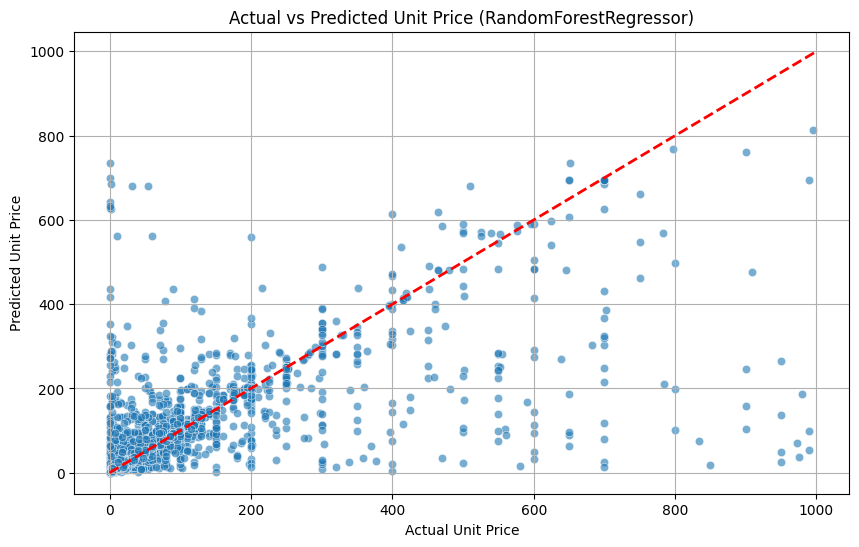

In [33]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Create a pipeline with preprocessing and a RandomForestRegressor model
model_pipeline = Pipeline(steps=[('preprocessor', preprocessor),
                               ('regressor', RandomForestRegressor(random_state=42, n_jobs=-1))])

# Train the model
print("Training the RandomForestRegressor model...")
model_pipeline.fit(X_train, y_train)
print("Model training complete.")

# Make predictions on the test set
y_pred = model_pipeline.predict(X_test)

# Evaluate the model
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f"\nModel Evaluation:")
print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
print(f"R-squared (R2): {r2:.2f}")

# Visualize predictions vs actuals
plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_test, y=y_pred, alpha=0.6)
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--', lw=2) # Line for perfect prediction
plt.xlabel('Actual Unit Price')
plt.ylabel('Predicted Unit Price')
plt.title('Actual vs Predicted Unit Price (RandomForestRegressor)')
plt.grid(True)
plt.show()

## **Feature Importance Analysis**

Top 20 Feature Importances:


,0
strength_value,0.214101
package_unit_pack,0.171543
package_quantity,0.149910
dosage form_SC Injection,0.049711
dosage form_Inhaler,0.031135
dosage form_IV Injection or Infusion,0.029688
manufacturer_Other,0.022840
dosage form_Syrup,0.018713
strength_unit_mg,0.017707
generic_Other,0.013239


/tmp/ipykernel_8146/131987973.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=feature_importances_sorted.head(20).values, y=feature_importances_sorted.head(20).index, palette='viridis')


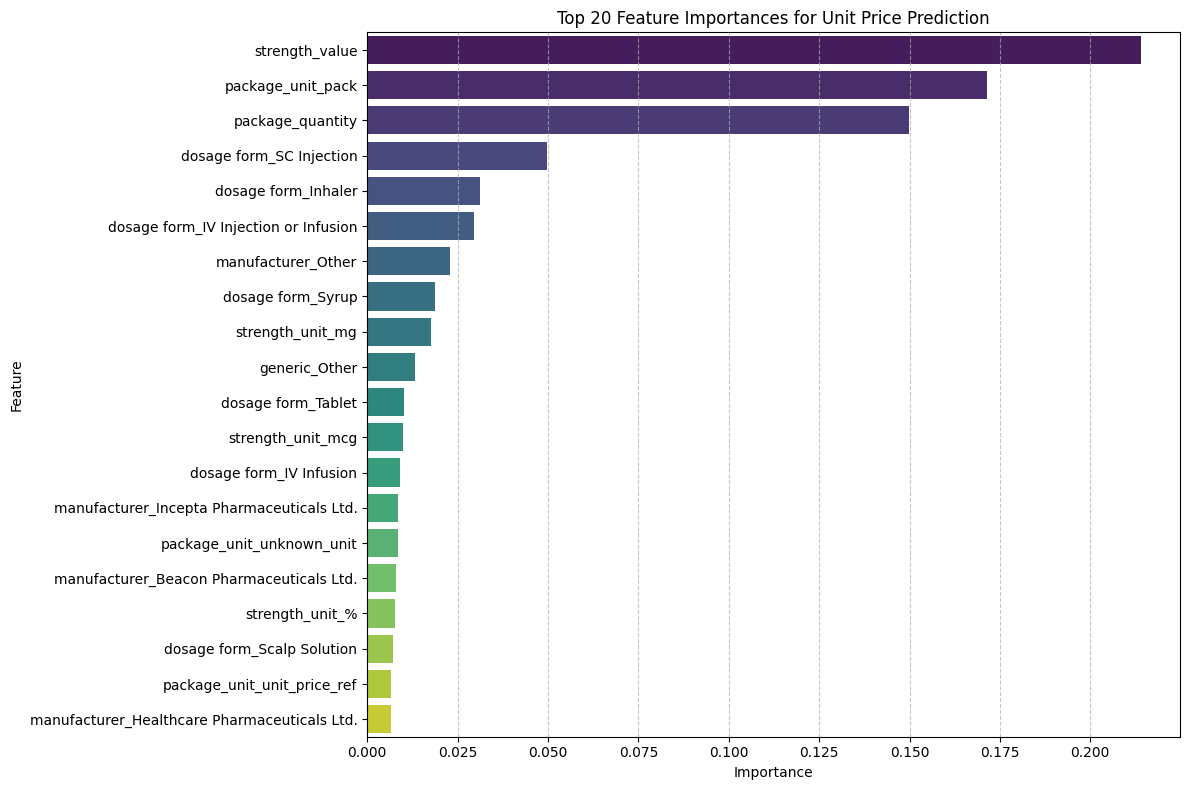

In [34]:
# Get feature importances from the trained RandomForestRegressor
# The preprocessor transforms the features, so we need to get the feature names correctly

# Get feature names after one-hot encoding
onehot_features = model_pipeline.named_steps['preprocessor'].named_transformers_['cat'].get_feature_names_out(categorical_features_reduced)
all_features = list(numerical_features) + list(onehot_features)

# Get importances from the regressor
importances = model_pipeline.named_steps['regressor'].feature_importances_

# Create a pandas Series for easier analysis
feature_importances = pd.Series(importances, index=all_features)

# Sort feature importances in descending order
feature_importances_sorted = feature_importances.sort_values(ascending=False)

# Display top 20 features
print("Top 20 Feature Importances:")
display(feature_importances_sorted.head(20))

# Plot feature importances
plt.figure(figsize=(12, 8))
sns.barplot(x=feature_importances_sorted.head(20).values, y=feature_importances_sorted.head(20).index, palette='viridis')
plt.title('Top 20 Feature Importances for Unit Price Prediction')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()